<a href="https://colab.research.google.com/github/CauaGraeff/Time_Caua/blob/main/time_do_cau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Apresentando o tema

Aqui vamos fazer uma analise de uma lista de pokemons para conseguir selecionar três pokémons para um time perfeito para uma batalha que ocorrerá na Dell, mas antes vamos colocar duas imagens que serão importantes para minha análise, uma que mostra que o que cada natureza modificar o pokémon e outra para mostra a vantagem e desvantagem de cada tipo de pokémon.

O que cada natureza beneficia o pokémon, considere que tem 5 naturezas que são neutras, sendo assim alteram nada:

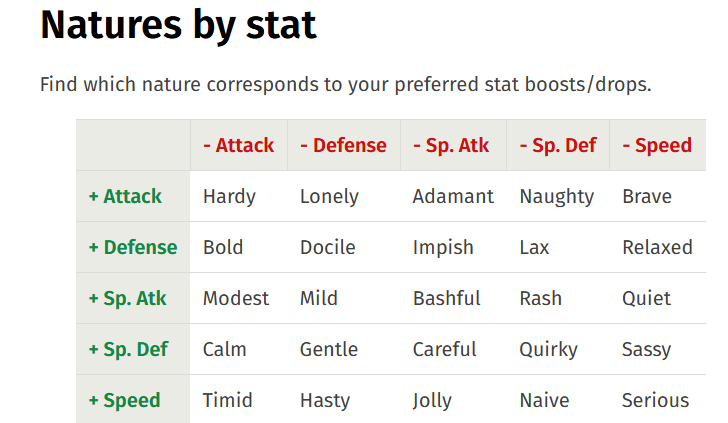

Vantagens e desvantagens de cada tipo de pokémon:

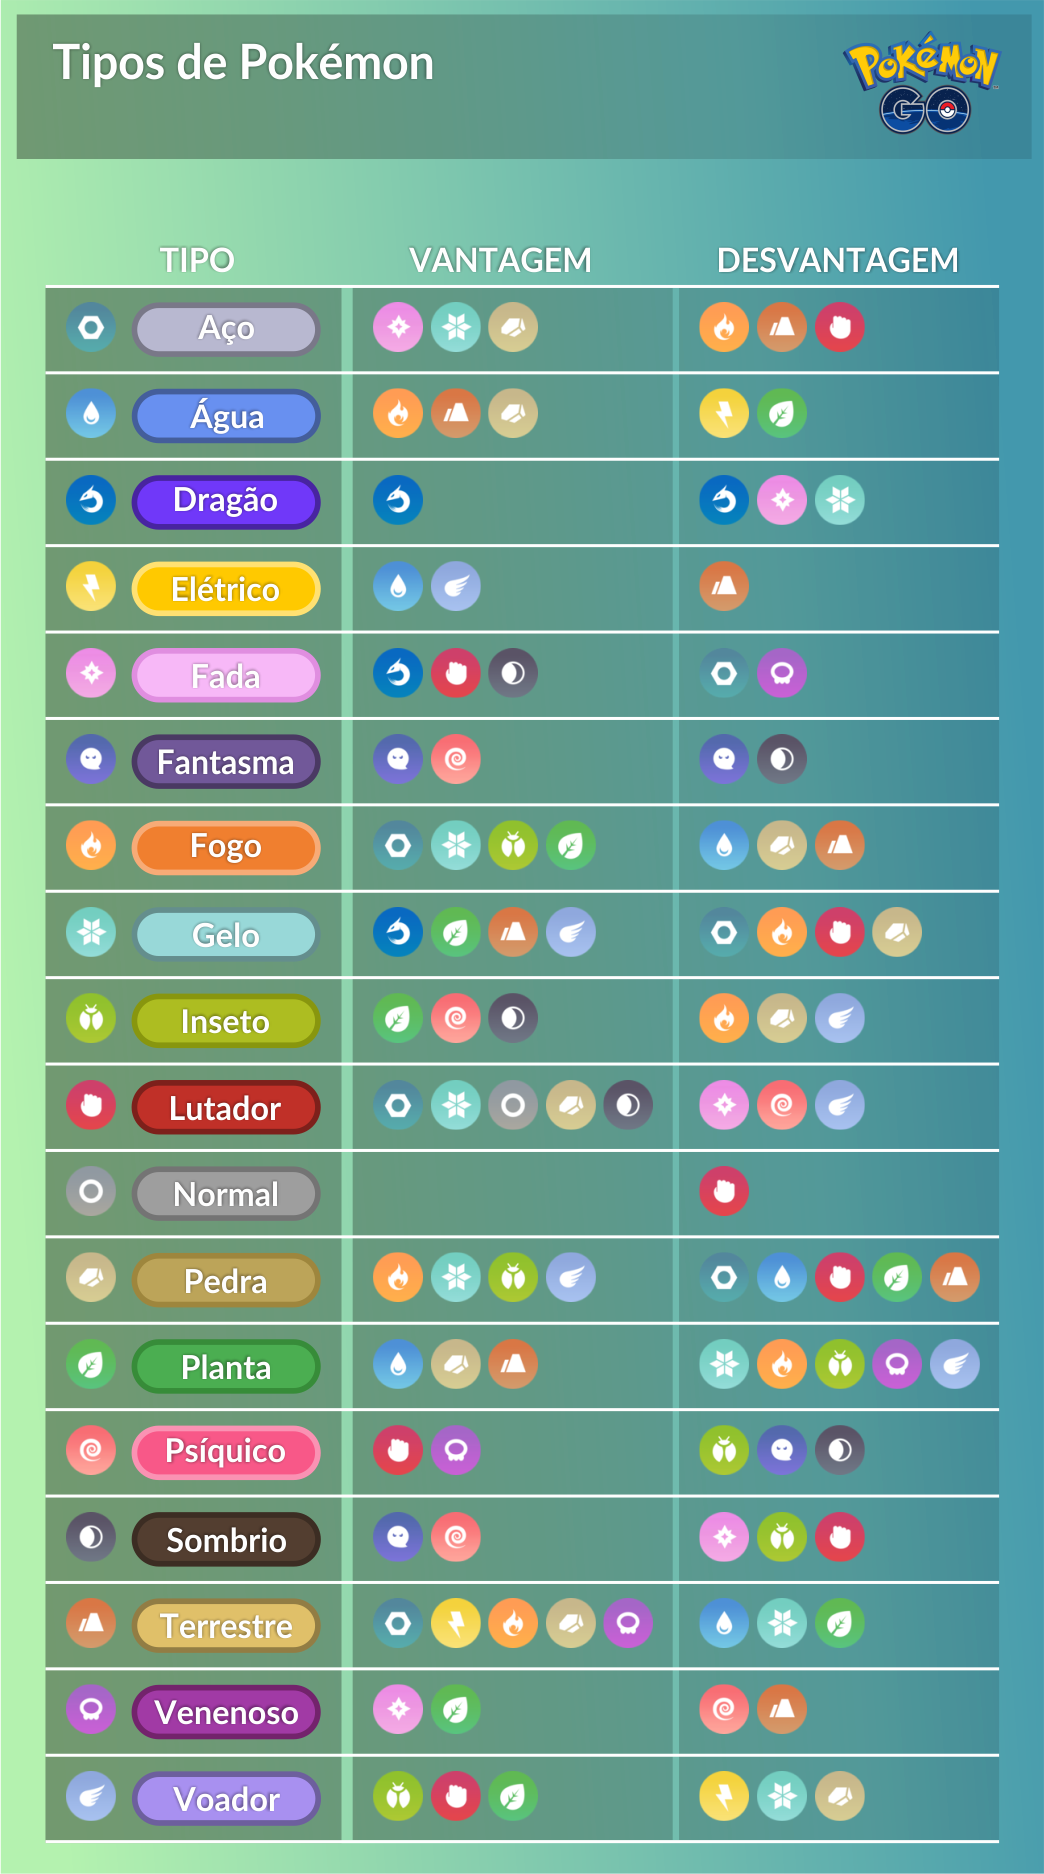

# Carregando os dados

Primeiramente, nós importamos as bibliotecas necessárias para a analise.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests as req

Agora nós carregaremos os nossos dados.

In [ ]:
raw_data = req.get('https://batalha-pokemon-cbc1c71b98dd.herokuapp.com/pokemons')
data = raw_data.json()
pokemons = pd.DataFrame(data["data"])
pokemons

,id,nome,nivel,sexo,tipos,movimentos,habilidade,natureza,cur_hp,stats,imagem,legendario,mitico,geracao,danos
0,1,bulbasaur,1,female,"[grass, poison]","[quick-attack, cross-poison]",chlorophyll,serious,45,"[45, 49, 49, 65, 65, 45]",https://raw.githubusercontent.com/PokeAPI/spri...,False,False,generation-i,"{'recebe_dano_duplo': ['psychic', 'poison', 'i..."
1,2,ivysaur,1,male,"[grass, poison]","[energy-ball, sludge-bomb]",overgrow,hardy,60,"[60, 62, 63, 80, 80, 60]",https://raw.githubusercontent.com/PokeAPI/spri...,False,False,generation-i,"{'recebe_dano_duplo': ['psychic', 'poison', 'i..."
2,3,venusaur,1,male,"[grass, poison]","[synthesis, magical-leaf]",chlorophyll,bashful,80,"[80, 82, 83, 100, 100, 80]",https://raw.githubusercontent.com/PokeAPI/spri...,False,False,generation-i,"{'recebe_dano_duplo': ['psychic', 'poison', 'i..."
3,4,charmander,1,male,[fire],"[sunny-day, fire-punch]",blaze,bashful,39,"[39, 52, 43, 50, 60, 65]",https://raw.githubusercontent.com/PokeAPI/spri...,False,False,generation-i,"{'recebe_dano_duplo': ['ground', 'water', 'roc..."
4,5,charmeleon,1,male,[fire],"[fire-spin, flare-blitz]",blaze,bashful,58,"[58, 64, 58, 65, 80, 80]",https://raw.githubusercontent.com/PokeAPI/spri...,False,False,generation-i,"{'recebe_dano_duplo': ['ground', 'water', 'roc..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,10160,pikachu-world-cap,1,genderless,[electric],"[zap-cannon, zap-cannon]",lightning-rod,hardy,35,"[35, 55, 40, 50, 50, 90]",https://raw.githubusercontent.com/PokeAPI/spri...,False,False,generation-i,"{'recebe_dano_duplo': ['ground'], 'recebe_dano..."
496,10250,tauros-paldea-combat-breed,1,male,[fighting],"[seismic-toss, close-combat]",anger-point,serious,75,"[75, 110, 105, 70, 30, 100]",https://raw.githubusercontent.com/PokeAPI/spri...,False,False,generation-i,"{'recebe_dano_duplo': ['fairy', 'psychic', 'fl..."
497,10251,tauros-paldea-blaze-breed,1,genderless,"[fighting, fire]","[mach-punch, focus-blast]",intimidate,bashful,75,"[75, 110, 105, 70, 30, 100]",https://raw.githubusercontent.com/PokeAPI/spri...,False,False,generation-i,"{'recebe_dano_duplo': ['water', 'psychic', 'fa..."
498,10252,tauros-paldea-aqua-breed,1,female,"[fighting, water]","[low-kick, muddy-water]",anger-point,docile,75,"[75, 110, 105, 70, 30, 100]",https://raw.githubusercontent.com/PokeAPI/spri...,False,False,generation-i,"{'recebe_dano_duplo': ['psychic', 'fairy', 'gr..."


Com os dados escolhidos, vamos agora arrumar os dados, como por exemplo separar a coluna tipos em tipo_1 e tipo_2, separar os stats em outras colunas, entre outros para conseguir fazer uma melhor análise entre as linhas.

In [ ]:
analise = pokemons[['nome',
                    'id',
                    'tipos',
                    'stats',
                    'movimentos',
                    'habilidade',
                    'natureza',
                    'mitico']]
analise['hp'] = analise['stats'].apply(lambda x: x[0])
analise['ataque'] = analise['stats'].apply(lambda x: x[1])
analise['defesa'] = analise['stats'].apply(lambda x: x[2])
analise['defesa_especial'] = analise['stats'].apply(lambda x: x[3])
analise['ataque_especial'] = analise['stats'].apply(lambda x: x[4])
analise['velocidade'] = analise['stats'].apply(lambda x: x[5])
analise['tipo_1'] = analise['tipos'].apply(lambda x: x[0])
analise['tipo_2'] = analise['tipos'].apply(lambda x: x[1] if len(x) > 1 else None)
analise['movimento_1'] = analise['movimentos'].apply(lambda x: x[0])
analise['movimento_2'] = analise['movimentos'].apply(lambda x: x[1] if len(x) > 1 else None)
analise = analise.drop(columns=['stats', 'tipos','movimentos'])
analise

/tmp/ipykernel_890/4043331058.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_890/4043331058.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_890/4043331058.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_890/4

,nome,id,habilidade,natureza,mitico,hp,ataque,defesa,defesa_especial,ataque_especial,velocidade,tipo_1,tipo_2,movimento_1,movimento_2
0,bulbasaur,1,chlorophyll,serious,False,45,49,49,65,65,45,grass,poison,quick-attack,cross-poison
1,ivysaur,2,overgrow,hardy,False,60,62,63,80,80,60,grass,poison,energy-ball,sludge-bomb
2,venusaur,3,chlorophyll,bashful,False,80,82,83,100,100,80,grass,poison,synthesis,magical-leaf
3,charmander,4,blaze,bashful,False,39,52,43,50,60,65,fire,None,sunny-day,fire-punch
4,charmeleon,5,blaze,bashful,False,58,64,58,65,80,80,fire,None,fire-spin,flare-blitz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,pikachu-world-cap,10160,lightning-rod,hardy,False,35,55,40,50,50,90,electric,None,zap-cannon,zap-cannon
496,tauros-paldea-combat-breed,10250,anger-point,serious,False,75,110,105,70,30,100,fighting,None,seismic-toss,close-combat
497,tauros-paldea-blaze-breed,10251,intimidate,bashful,False,75,110,105,70,30,100,fighting,fire,mach-punch,focus-blast
498,tauros-paldea-aqua-breed,10252,anger-point,docile,False,75,110,105,70,30,100,fighting,water,low-kick,muddy-water


Com os dados arrumados, agora vamos fazer nossas análises

# Analise por stats

Um dos pokémons que eu quero selecionar precisa ter um dos stats mais altos que tiver possivel e que não seja pokémon mitico e lendário.

In [ ]:
stats = analise.query('hp >= 80')
stats = stats.query('ataque >= 85')
stats = stats.query('defesa >= 80')
stats = stats.query('defesa_especial >= 80')
stats = stats.query('ataque_especial >= 80')
stats = stats.query('velocidade >= 80')
stats = stats.query('mitico == False')
stats

,nome,id,habilidade,natureza,mitico,hp,ataque,defesa,defesa_especial,ataque_especial,velocidade,tipo_1,tipo_2,movimento_1,movimento_2
58,arcanine,59,flash-fire,quirky,False,90,110,80,80,100,95,fire,None,flare-blitz,ember
145,dragonite,149,inner-focus,bashful,False,91,134,95,100,100,80,dragon,flying,drill-peck,roost
320,flygon,330,levitate,hardy,False,80,100,80,80,80,100,ground,dragon,fissure,mud-sport
363,salamence,373,intimidate,bashful,False,95,135,80,80,110,100,dragon,flying,drill-peck,sky-attack
426,garchomp,445,sand-veil,docile,False,108,130,95,85,80,102,dragon,ground,dragon-rush,dragon-rush


Olhando para a tabela criada acima, podemos ver ótimos pokemons com stats bons, talvez um ou dois deles venham para o time, mais para baixo vamos ver o porque alguns pokémons não vou escolher e qual deles será. Considere que alguns só vão está resumindo, já que é por causa de um fator que eu não vou selecionar ele.

In [ ]:
gráfico_teia = pd.DataFrame(dict(
   r=[stats['hp'][145],
      stats['ataque'][145],
      stats['defesa'][145],
      stats['defesa_especial'][145],
      stats['ataque_especial'][145],
      stats['velocidade'][145]],
   theta=['hp', 'ataque', 'defesa', 'defesa especial', 'ataque especial','velocidade']
))

fig = px.line_polar(gráfico_teia, r='r', theta='theta', line_close=True)
configuração = {
    "title": {"text": "Dragonite"},
}
fig.update_layout(configuração)
fig.show()

O Dragonite, é um forte concorrente para ser do meu time, já que é um pokémon do tipo voador e dragão, tendo como gênero feminino.

Movimentos:

drill peck = é um ataque forte do tipo voador, com poder 80, com 100% de accuracy, podendo ser utilizado 20 vezes, ele também pode acertar pokémons adjacentes em batalhas triplas.

roost = Esse movimento é mais de cura, no caso recuperar metade da vida do pokémon que utilizou, detalhe ele perde o tipo voador temporariamente, o movimento é do tipo voador e pode ser utilizado 5 vezes, mas das gerações 4 a 8 pode ser utilizado 10 vezes.

habilidade:

inner foccus = é uma habilidade, no qual impede o pokémon de ser impedido dele vacilar na hora de atacar, caso ele sofra de algum golpe específico que o impeça de executar um golpe.

natureza:

bashful = natureza neutra.



In [ ]:
gráfico_teia = pd.DataFrame(dict(
   r=[stats['hp'][58],
      stats['ataque'][58],
      stats['defesa'][58],
      stats['defesa_especial'][58],
      stats['ataque_especial'][58],
      stats['velocidade'][58]],
   theta=['hp', 'ataque', 'defesa', 'defesa especial', 'ataque especial','velocidade']
))

fig = px.line_polar(gráfico_teia, r='r', theta='theta', line_close=True)
configuração = {
    "title": {"text": "Arcanine"},
}
fig.update_layout(configuração)
fig.show()

O Arcanine, mesmo possuindo stats bons, eu não vou querer ele no meu time, por conta dele ter apenas um tipo, meu plano é que meu time possua três pokémons, no qual cada um possua 2 tipos diferentes, no caso vai ter 6 tipos diferentes um do outro.

In [ ]:
gráfico_teia = pd.DataFrame(dict(
   r=[stats['hp'][320],
      stats['ataque'][320],
      stats['defesa'][320],
      stats['defesa_especial'][320],
      stats['ataque_especial'][320],
      stats['velocidade'][320]],
   theta=['hp', 'ataque', 'defesa', 'defesa especial', 'ataque especial','velocidade']
))

fig = px.line_polar(gráfico_teia, r='r', theta='theta', line_close=True)
configuração = {
    "title": {"text": "Flygon"},
}
fig.update_layout(configuração)
fig.show()

O flygon é um caso diferente, por conta de que nenhum dos seus movimentos causará dano aos adversários.

In [ ]:
gráfico_teia = pd.DataFrame(dict(
   r=[stats['hp'][363],
      stats['ataque'][363],
      stats['defesa'][363],
      stats['defesa_especial'][363],
      stats['ataque_especial'][363],
      stats['velocidade'][363]],
   theta=['hp', 'ataque', 'defesa', 'defesa especial', 'ataque especial','velocidade']
))

fig = px.line_polar(gráfico_teia, r='r', theta='theta', line_close=True)
configuração = {
    "title": {"text": "Salamence"},
}
fig.update_layout(configuração)
fig.show()

O salamence é um forte concorrente para ser do meu time, já que ele é do tipo dragão e voador, tendo como gênero genderless, no caso desconhecido.

movimentos:

drill peck = é um ataque forte do tipo voador, com poder 80, com 100% de accuracy, podendo ser utilizado 20 vezes, ele também pode acertar pokémons adjacentes em batalhas triplas.  

sky attack = é um ataque poderoso do tipo voador, com poder 140, com 90% de accuracy, podendo ser utilizado 5 vezes, tem um detalhe ele precisa ser carregado, no caso eu ativo ele num turno e ele fica sem atacar naquele turno, mas no próximo ele executará golpe referente ao segundo turno, portanto eu não poderei usar outro movimento no segundo turno, mas quando acerta, causará um dano gigantesco.

habilidade:

intimidade = é uma habilidade, no qual diminuir o ataque de todos os pokemons na arena, quando o pokemon com essa habilidade entra na arena, até mesmo no início da batalha.

natureza:

bashful = neutro


In [ ]:
gráfico_teia = pd.DataFrame(dict(
   r=[stats['hp'][426],
      stats['ataque'][426],
      stats['defesa'][426],
      stats['defesa_especial'][426],
      stats['ataque_especial'][426],
      stats['velocidade'][426]],
   theta=['hp', 'ataque', 'defesa', 'defesa especial', 'ataque especial','velocidade']
))

fig = px.line_polar(gráfico_teia, r='r', theta='theta', line_close=True)
configuração = {
    "title": {"text": "Garchomp"},
}
fig.update_layout(configuração)
fig.show()

Ele seria uma ótima opção de escolha para o time se fosse pelos stats, porém o pokémon só tem dragon rush como movimento, sendo do tipo dragão, vale lembra que pokémons do tipo fada são imunes a esse golpe.

# Escolha de pokémon do tipo terra

Aqui vamos selecionar 1 pokémon do tipo terra, já que eles possuem vantagem contra 5 tipos de pokémons, sendo eles aço, elétrico, fogo, pedra e veneno. Vamos levar em conta que eu vou usa os stats como critério para escolher meu pokémon do tipo terra.

In [ ]:
ground = analise.query('tipo_1 == "ground"')
ground = pd.concat([ground, analise.query('tipo_2 == "ground"')])
stats1 = ground.query('hp >= 80')
stats1 = stats1.query('ataque >= 70')
stats1 = stats1.query('defesa >= 70')
stats1 = stats1.query('defesa_especial >= 70')
stats1 = stats1.query('ataque_especial >= 70')
stats1 = stats1.query('velocidade >= 70')
stats1 = stats1.query('mitico == False')
stats1

,nome,id,habilidade,natureza,mitico,hp,ataque,defesa,defesa_especial,ataque_especial,velocidade,tipo_1,tipo_2,movimento_1,movimento_2
320,flygon,330,levitate,hardy,False,80,100,80,80,80,100,ground,dragon,fissure,mud-sport
30,nidoqueen,31,poison-point,serious,False,90,92,87,85,75,76,poison,ground,poison-fang,bone-rush
33,nidoking,34,rivalry,docile,False,81,102,77,75,85,85,poison,ground,mud-bomb,gunk-shot
426,garchomp,445,sand-veil,docile,False,108,130,95,85,80,102,dragon,ground,dragon-rush,dragon-rush


Agora vamos analisar cada um individualmente, detalhe garchomp e flygon não vão ser analisados por conta do que eu falei na seção anterior.

In [ ]:
gráfico_teia = pd.DataFrame(dict(
   r=[stats1['hp'][30],
      stats1['ataque'][30],
      stats1['defesa'][30],
      stats1['defesa_especial'][30],
      stats1['ataque_especial'][30],
      stats1['velocidade'][30]],
   theta=['hp', 'ataque', 'defesa', 'defesa especial', 'ataque especial','velocidade']
))

fig = px.line_polar(gráfico_teia, r='r', theta='theta', line_close=True)
configuração = {
    "title": {"text": "Nidoqueen"},
}
fig.update_layout(configuração)
fig.show()

A Nidoqueen é uma forte competidora para fazer parte do meu time, por conta que ela é do tipo veneno e terra, tendo como gênero genderless, no caso é desconhecido, porém nidoqueen normalmente é feminino.

movimentos:

poison-fang  = é um ataque mediano do tipo veneno, com poder 50, com 100% de accuracy, podendo ser utilizado 10 vezes na partida, nas primeiras gerações ele tem 50% de chance de causa envenenamento grave, porém nas gerações 3, 4 e 5 é 30%, o envenenamento grave causa dano crescente de HP a cada turno.

bone-rush = esse ataque é fraco do tipo terra, com poder 25, com 90% de accuracy, podendo ser utilizado 10 vezes, mas o pouco de dano que ele causa é por conta que é um golpe consecutivo que pode acertar 5 vezes em um ataque só, tendo como poder 125, mas considere quanto mais acertos tiver, menor a chance do próximo golpe dá certo, vamos levar em conta que cada golpe é contado separadamente, sendo assim um golpe pode ser normal e outro causar um golpe crítico.

habilidade:

poison-point = Caso o pokémon adversario entre em contato com a nidoqueen, ele poderá ser envenenado.

natureza:

serious = natureza neutra.


In [ ]:
gráfico_teia = pd.DataFrame(dict(
   r=[stats1['hp'][33],
      stats1['ataque'][33],
      stats1['defesa'][33],
      stats1['defesa_especial'][33],
      stats1['ataque_especial'][33],
      stats1['velocidade'][33]],
   theta=['hp', 'ataque', 'defesa', 'defesa especial', 'ataque especial','velocidade']
))

fig = px.line_polar(gráfico_teia, r='r', theta='theta', line_close=True)
configuração = {
    "title": {"text": "Nidoking"},
}
fig.update_layout(configuração)
fig.show()

O Nidoking é um forte competidor para ser do meu time, já que ele é do tipo veneno e terra, tendo com gênero feminino, sendo que o Nidoking, obrigatoriamente, era para ser masculino.

movimentos:

mud bomb  = é um ataque especial mediano do tipo terra, com poder de 65 com 85% de accuracy, podendo ser usado 10 vezes na partida, podendo diminuir a precisão do ataque do inimigo.

gunk-shot = é um ataque forte do tipo veneno, com poder de 120 com 80% de accuracy, podendo ser utilizado 5 vezes na partida e tem 30% de chance de envenenar o inimigo.

habilidade:

rivalry = causa mais dano a um pokemon do mesmo gênero.

natureza:

docile = natureza neutra.


# Escolha de pokémon do tipo lutador

Escolherei um pokémon do tipo lutador, por conta que ele é que nem o tipo terra, que tem vantagem sobre 5 tipos de pokémons, sendo eles aço, gelo, normal, pedra e sombrio, agora vamos ver as opções de lutadores. Vamos levar em conta que eu vou usa os stats como critério para escolher meu pokémon do tipo lutador.

In [ ]:
fighting = analise.query('tipo_1 == "fighting"')
fighting = pd.concat([fighting, analise.query('tipo_2 == "fighting"')])
stats2 = fighting.query('hp >= 70')
stats2 = stats2.query('ataque >= 90')
stats2 = stats2.query('defesa >= 70')
stats2 = stats2.query('defesa_especial >= 70')
stats2 = stats2.query('ataque_especial >= 70')
stats2 = stats2.query('velocidade >= 80')
stats2 = stats2.query('mitico == False')
stats2

,nome,id,habilidade,natureza,mitico,hp,ataque,defesa,defesa_especial,ataque_especial,velocidade,tipo_1,tipo_2,movimento_1,movimento_2
429,lucario,448,inner-focus,quirky,False,70,110,70,70,115,90,fighting,steel,bullet-punch,vacuum-wave
247,blaziken,257,speed-boost,bashful,False,80,120,70,70,110,80,fire,fighting,wake-up-slap,hammer-arm
373,infernape,392,iron-fist,hardy,False,76,104,71,71,104,108,fire,fighting,double-kick,brick-break


com os tipos lutadores decidido, vamos agora ver cada um separadamente.

In [ ]:
gráfico_teia = pd.DataFrame(dict(
   r=[stats2['hp'][429],
      stats2['ataque'][429],
      stats2['defesa'][429],
      stats2['defesa_especial'][429],
      stats2['ataque_especial'][429],
      stats2['velocidade'][429]],
   theta=['hp', 'ataque', 'defesa', 'defesa especial', 'ataque especial','velocidade']
))

fig = px.line_polar(gráfico_teia, r='r', theta='theta', line_close=True)
configuração = {
    "title": {"text": "Lucario"},
}
fig.update_layout(configuração)
fig.show()

Lucario é um forte competidor para fazer parte do meu time, já que ele é do tipo lutador e aço, tendo como gênero masculino.

movimentos
:
bullet-punch = é um ataque fraco do tipo aço, com poder de 30, com 100% de accuracy, podendo ser utilizado 30 vezes na partida, ele é um movimento prioritário, no caso ele ataca primeiro, independente da velocidade do pokemon, mas se o outro usar também um movimento prioritário, o mais veloz ganha.

vacuum-wave = é um ataque especial do tipo lutador, com poder de 40, com 100% de accuracy, podendo ser utilizado 30 vezes na partida, sendo também um movimento prioritário, como já explicado acima.

habilidade:

inner-focus = Essa habilidade impede que o pokemon vacile quando atacar, caso um ataque impeça ele de atacar.

natureza:

quirky = natureza neutra


In [ ]:
gráfico_teia = pd.DataFrame(dict(
   r=[stats2['hp'][373],
      stats2['ataque'][373],
      stats2['defesa'][373],
      stats2['defesa_especial'][373],
      stats2['ataque_especial'][373],
      stats2['velocidade'][373]],
   theta=['hp', 'ataque', 'defesa', 'defesa especial', 'ataque especial','velocidade']
))

fig = px.line_polar(gráfico_teia, r='r', theta='theta', line_close=True)
configuração = {
    "title": {"text": "Infernape"},
}
fig.update_layout(configuração)
fig.show()

Infernape é forte competidor para fazer parte do time, sendo considerado um pokémon do tipo fogo e lutador tendo como gênero feminino.

movimentos:

double-kick = é um ataque fraco do tipo lutador, com poder 30, com 100% de accuracy, podendo ser utilizado 30 vezes na partida, sendo que ele dar dois golpes consecutivos, sendo considerados separados, portanto o crítico pode ocorrer em um, mas no outro não.

brick-break = é um ataque forte do tipo lutador, com poder 75, com 100% de accuracy, podendo ser utilizado 15 vezes, considere que ele remove os efeitos de reflect e light screen do pokémon que utilizar.

habilidade:

iron-fist = essa habilidade, basicamente aumenta em 20% o ataque de todos os golpes de soco.

natureza:

hardy = natureza neutra.



In [ ]:
gráfico_teia = pd.DataFrame(dict(
   r=[stats2['hp'][247],
      stats2['ataque'][247],
      stats2['defesa'][247],
      stats2['defesa_especial'][247],
      stats2['ataque_especial'][247],
      stats2['velocidade'][247]],
   theta=['hp', 'ataque', 'defesa', 'defesa especial', 'ataque especial','velocidade']
))

fig = px.line_polar(gráfico_teia, r='r', theta='theta', line_close=True)
configuração = {
    "title": {"text": "Blaziken"},
}
fig.update_layout(configuração)
fig.show()

Blaziken é um forte competidor para fazer parte do meu time, sendo um pokémon do tipo fogo e lutador, tendo como gênero masculino.

movimentos:
wake-up-slap = é um ataque forte do tipo lutador, com poder 70, com 100% de accuracy, podendo ser utilizado 10 vezes, detalhe nas gerações 4 e 5 ele tem poder 60, um benefício dessa habilidade é que se caso o pokémon estiver dormindo, ele causa o dobro de dano, mas claro acordará o pokémon que estiver dormindo.

hammer-arm = é um ataque forte do tipo lutador, com poder 100, com 90% de accuracy, podendo ser utilizado 10 vezes, porém reduz a velocidade do inimigo.

habilidade:

speed-boost = A estatística de velocidade dele vai aumentando gradualmente.

natureza:

bashful = natureza neutra.



# Time do Cauã

Conclusão:

Após várias analises eu pode concluir quem será meu time e quais seriam os motivos, agora serão explicados abaixo, detalhe eles já estaram em ordem que eu vou colocar eles para a batalha:

Primeiro pokémon:

Nidoqueen, eu escolhi ele por conta de seus movimentos e de sua habilidade, já que os movimentos são fortes e mais precisos, sendo que o do tipo veneno poderá envenenar gravemente o inimigo, além do movimento do tipo terra ser em sequência e causar muito dano. Além é claro da habilidade que se caso encosterem nele físicamente, o inimigo poderá ser envenenado, por conta desses vários fatores ele será nosso primeiro pokémon a entrar em batalha e se ele for derrotado pelo menos terá a chance de envenenar o inimigo para o próximo pokémon ter mais chance de derrotar ele. O Nidoking também era uma ótima opção, mas a habilidade e os movimentos deles não são tão bons que nem a da Nidoqueen.

Segundo pokémon:

Blaziken, para o tipo lutador foi díficil escolher, mas eu decidi ir de Blaziken, mesmo que ele e os outros dois pokémons tenham stats equilibrados, as habilidades e os movimentos não os ajudam muito, por exemplo Infernape tem dois golpes do tipo lutador, sendo até que balanceados, porém a habilidade dele não ajuda, já que ela só aumenta o dano de movimentos de soco, e os dois movimentos dele não são de socos. Já o Lucario foi por conta de que seus movimentos não causam muito dano nos outros pokémons, mesmo que sejam prioritários, não ajudariam muito na batalha, só em alguns casos ajudariam. Agora eu escolhi o Blaziken por alguns motivos, primeiro a sua habilidade, a cada turno o Blaziken tem a sua velocidade aumentada, sendo assim fica mais veloz e atacando antes do pokémon inimigo atacar, também temos os seus dois movimentos, um que causa já um dano alto e se o pokémon inimigo estiver dormindo tomará o dobro de dano e o outro movimento causa bastante dano e ainda por cima diminuí a velocidade do pokémon inimigo, então imagina só, o Blaziken já está ficando cada vez mais rápido e ainda por cima está diminuindo a velocidade do pokémon inimigo, seria um combo op, já que ele basicamente atacaria em quase todos os turnos primeiro. Tem um detalhe ele vai ser o segundo pokémon a entrar em batalha, por conta de que ele possui dois golpes do tipo lutador, então imagina só me aparece um pokémon do tipo fantasma como último, eu me ferraria um monte, logo ele vai ficar como segundo para dar uma surra e detorna vários pokémons.

Terceiro pokémon:

Dragonite, muitos pensariam que salamence seria o melhor pokémon no lugar de Dragonite, mas estavam errado, quando eu fui fazer um teste com o time, percebi que o Dragonite tinha muita vantagem nas batalhas, por conta do seu movimento de cura, fazendo com que ele dure por muito mais tempo e sendo considerado a última opção caso meu time esteja em desvantagem numérica, ele era para ser o segundo pokémon, porém por conta do blaziken ter só movimentos do tipo lutador, acabou que o Dragonite teve que ficar em último.